<a href="https://colab.research.google.com/github/Karan-Potdukhe/AI-ML-DL-Hacktoberfest2024-WB/blob/Karan-Potdukhe-patch-1/1_Main_ANN_MNIST_Noise_Reduction_Using_Auto_Encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import GaussianNoise

from tensorflow.keras.datasets import mnist

In [ ]:
#importing the data
(X_train,y_train),(X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


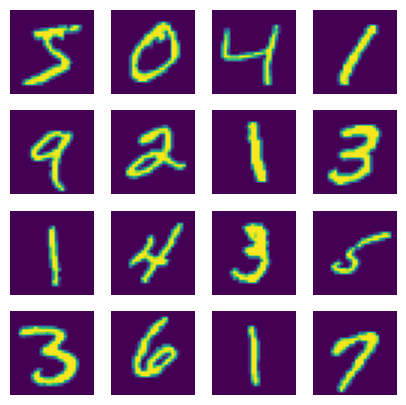

In [ ]:
#plotting the images
plt.figure(figsize=(5,5))

for i in range(16):
  plt.subplot(4,4,i+1)
  plt.axis("off")
  plt.imshow(X_train[i])
plt.show()

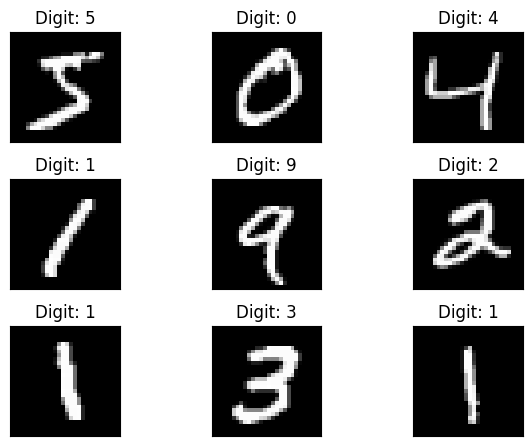

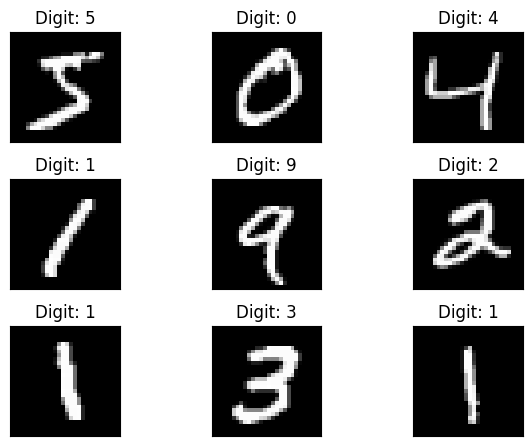

In [ ]:
fig = plt.figure()
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.tight_layout()
  plt.imshow(X_train[i], cmap='gray', interpolation='none')
  plt.title("Digit: {}".format(y_train[i]))
  plt.xticks([])
  plt.yticks([])
fig

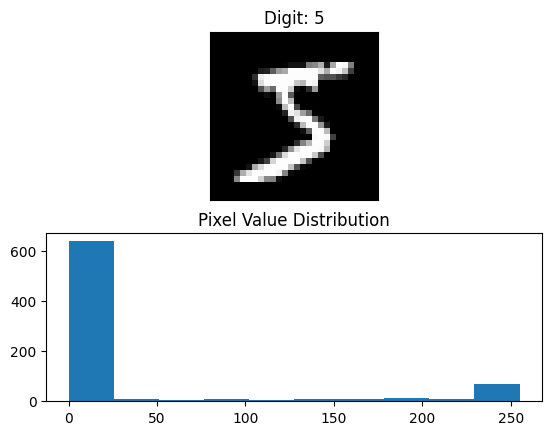

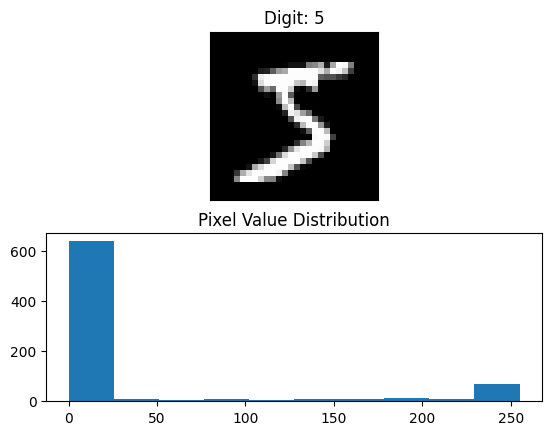

In [ ]:
fig = plt.figure()
plt.subplot(2,1,1)
plt.imshow(X_train[0], cmap='gray', interpolation='none')
plt.title("Digit: {}".format(y_train[0]))
plt.xticks([])
plt.yticks([])
plt.subplot(2,1,2)
plt.hist(X_train[0].reshape(784))
plt.title("Pixel Value Distribution")
fig

In [ ]:
#normalising the data
X_train = X_train/255.0

X_test = X_test/255.0

In [ ]:
#introducing the noise in the data
noise = GaussianNoise(0.4)

noisy_image = noise(X_train[:16], training =True)

Actual Image


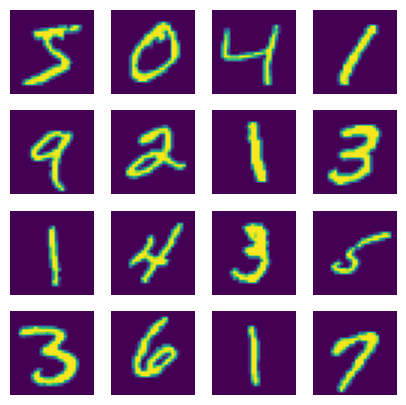

Noisy Image


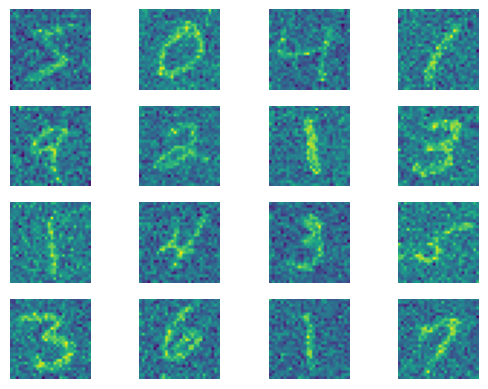

In [ ]:
#plotting actual image and noisy image
plt.figure(figsize=(5,5))

print("Actual Image")
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.axis("off")
  plt.imshow(X_train[i])
plt.show()

print("Noisy Image")
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.axis("off")
  plt.imshow(noisy_image[i])
plt.show()

In [ ]:

#defining units and setting seeds
units = 28*28

tf.random.set_seed(101)

In [ ]:
#building encoder
encoder = Sequential()

encoder.add(Flatten(input_shape = [28,28])) #784
encoder.add(GaussianNoise(0.4))
encoder.add(Dense(392, activation="relu")) #392
encoder.add(Dense(196, activation="relu")) #196
encoder.add(Dense(98, activation="relu")) # 98
encoder.add(Dense(49, activation="relu"))#49
encoder.add(Dense(24, activation="relu"))#24
encoder.add(Dense(12, activation="relu"))#12

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gaussian_noise_1 (GaussianNoise)     │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 392)                 │         307,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 196)                 │          77,028 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 98)                  │          19,306 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 49)                  │           4,851 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 24)                  │           1,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 12)                  │             300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 410,405 (1.57 MB)

 Trainable params: 410,405 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#building decoder
decoder = Sequential()
decoder.add(Dense(units = 24, input_shape = [12], activation="relu"))
decoder.add(Dense(units = 49, activation="relu"))
decoder.add(Dense(units = 98, activation="relu"))
decoder.add(Dense(units = 196, activation="relu"))
decoder.add(Dense(units = 392, activation="relu"))
decoder.add(Dense(784, activation="sigmoid"))
decoder.add(Reshape([28,28]))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 24)                  │             312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 49)                  │           1,225 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 98)                  │           4,900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 196)                 │          19,404 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 392)                 │          77,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 784)                 │         308,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28)              │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 411,177 (1.57 MB)

 Trainable params: 411,177 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#combining encoder and decoder
noise_red = Sequential([encoder,decoder])

In [ ]:
#compiling the model
noise_red.compile(loss = "binary_crossentropy", optimizer="adam", metrics = ["accuracy"])

In [ ]:
#training the model
noise_red.fit(X_train,X_train, epochs=50)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.1083 - loss: 0.2399
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.2007 - loss: 0.1592
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2155 - loss: 0.1468
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2242 - loss: 0.1394
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2288 - loss: 0.1355
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2319 - loss: 0.1330
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2356 - loss: 0.1311
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.2370 - loss: 0.1299
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2400 - loss: 0.1286
Epoch 10/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2416 - loss: 0.1278
Epoch 11/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.2421 - loss: 0.1269
Epoch 12/50
1875/1875 ━━━━

In [ ]:
#creating noisy image
test_noise = noise(X_test[:10], training = True)

In [ ]:
#cleaning the data using model
clean_test_image = noise_red(test_noise)

Original


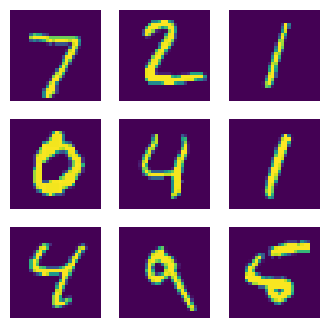

Noisy


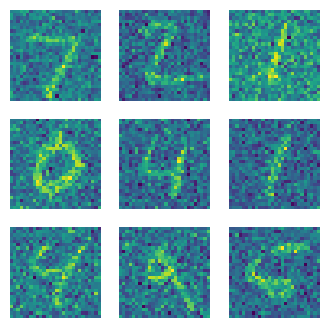

Auto-Encoder Image


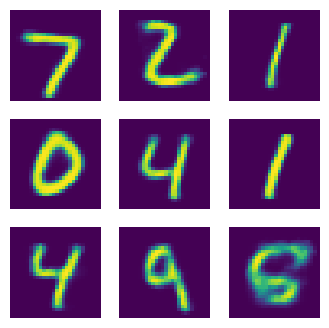

In [ ]:
#printing Actual, Noisy and Image cleaned by the model
print("Original")
plt.figure(figsize=(4, 4))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.axis("off")
    plt.imshow(X_test[i])
plt.show()

print("Noisy")
plt.figure(figsize=(4, 4))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.axis("off")
    plt.imshow(test_noise[i])
plt.show()

print("Auto-Encoder Image")
plt.figure(figsize=(4, 4))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.axis("off")
    plt.imshow(clean_test_image[i])
plt.show()